In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [1]:
import os

for root, dirs, files in os.walk("../data_raw"):
    if "machine_temperature_system_failure.csv" in files:
        print("Found:", os.path.join(root, "machine_temperature_system_failure.csv"))

Found: ../data_raw\nab\realKnownCause\realKnownCause\machine_temperature_system_failure.csv


In [3]:
path = "../data_raw/nab/realKnownCause/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(path)
df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

In [5]:
df.isna().sum()
df["value"].describe()

count    22695.000000
mean        85.926498
std         13.746912
min          2.084721
25%         83.080078
50%         89.408246
75%         94.016252
max        108.510543
Name: value, dtype: float64

In [4]:
s = df["value"].astype(float)

window = 50

features = pd.DataFrame({
    "value": s,
    "diff1": s.diff(),
    "roll_mean": s.rolling(window).mean(),
    "roll_std": s.rolling(window).std(),
    "roll_min": s.rolling(window).min(),
    "roll_max": s.rolling(window).max(),
})

features = features.dropna().reset_index(drop=True)
features.head()

NameError: name 'df' is not defined

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

NameError: name 'StandardScaler' is not defined

In [8]:
processed_path = "../data_processed/industrial_machine_features.csv"
features.to_csv(processed_path, index=False)

print("Saved to:", processed_path)

Saved to: ../data_processed/industrial_machine_features.csv


In [6]:
df = pd.read_csv("../data_processed/industrial_machine_features.csv")

df.head()

,value,diff1,roll_mean,roll_std,roll_min,roll_max
0,85.344624,0.161258,81.307319,2.262449,73.967322,85.344624
1,84.671962,-0.672663,81.521412,2.050229,74.935882,85.344624
2,85.302762,0.630800,81.728749,1.888464,76.124162,85.344624
3,84.349211,-0.953551,81.893250,1.742921,78.140707,85.344624
4,84.555844,0.206633,82.021553,1.696549,78.710418,85.344624


In [9]:
raw_path = "../data_raw/nab/realKnownCause/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(raw_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

anomaly_windows = [
    ("2013-12-10 06:25:00", "2013-12-12 05:35:00"),
    ("2013-12-15 17:50:00", "2013-12-17 17:00:00"),
    ("2014-01-27 14:20:00", "2014-01-29 13:30:00"),
    ("2014-02-07 14:55:00", "2014-02-09 14:05:00"),
]

anomaly_windows = [(pd.Timestamp(start), pd.Timestamp(end)) for start, end in anomaly_windows]

df["y_true"] = 0
for start, end in anomaly_windows:
    mask = (df["timestamp"] >= start) & (df["timestamp"] <= end)
    df.loc[mask, "y_true"] = 1

df["diff1"] = df["value"].diff()
df["roll_mean"] = df["value"].rolling(window=50).mean()
df["roll_std"] = df["value"].rolling(window=50).std()
df["roll_min"] = df["value"].rolling(window=50).min()
df["roll_max"] = df["value"].rolling(window=50).max()

df_features = df.dropna().reset_index(drop=True)

out_path = "../data_processed/industrial_machine_features_labeled.csv"
df_features.to_csv(out_path, index=False)

print(df_features.head())
print("Saved:", out_path)
print("Columns:", df_features.columns.tolist())
print("Anomaly count:", df_features["y_true"].sum())
print("Total rows:", len(df_features))

            timestamp      value  y_true     diff1  roll_mean  roll_std  \
0 2013-12-03 01:20:00  85.344624       0  0.161258  81.307319  2.262449   
1 2013-12-03 01:25:00  84.671962       0 -0.672663  81.521412  2.050229   
2 2013-12-03 01:30:00  85.302762       0  0.630800  81.728749  1.888464   
3 2013-12-03 01:35:00  84.349211       0 -0.953551  81.893250  1.742921   
4 2013-12-03 01:40:00  84.555844       0  0.206633  82.021553  1.696549   

    roll_min   roll_max  
0  73.967322  85.344624  
1  74.935882  85.344624  
2  76.124162  85.344624  
3  78.140707  85.344624  
4  78.710418  85.344624  
Saved: ../data_processed/industrial_machine_features_labeled.csv
Columns: ['timestamp', 'value', 'y_true', 'diff1', 'roll_mean', 'roll_std', 'roll_min', 'roll_max']
Anomaly count: 2268
Total rows: 22646


(22646, 8)
['timestamp', 'value', 'y_true', 'diff1', 'roll_mean', 'roll_std', 'roll_min', 'roll_max']
             timestamp      value  y_true     diff1  roll_mean  roll_std  \
0  2013-12-03 01:20:00  85.344624       0  0.161258  81.307319  2.262449   
1  2013-12-03 01:25:00  84.671962       0 -0.672663  81.521412  2.050229   
2  2013-12-03 01:30:00  85.302762       0  0.630800  81.728749  1.888464   
3  2013-12-03 01:35:00  84.349211       0 -0.953551  81.893250  1.742921   
4  2013-12-03 01:40:00  84.555844       0  0.206633  82.021553  1.696549   

    roll_min   roll_max  
0  73.967322  85.344624  
1  74.935882  85.344624  
2  76.124162  85.344624  
3  78.140707  85.344624  
4  78.710418  85.344624  

Rozdelenie meraní v datasete NAB:
             Trieda  Počet riadkov  Podiel (%)
0  Normálne merania          20378       89.98
1  Anomálne merania           2268       10.02
2             Spolu          22646      100.00


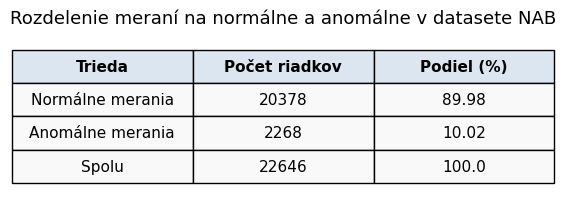

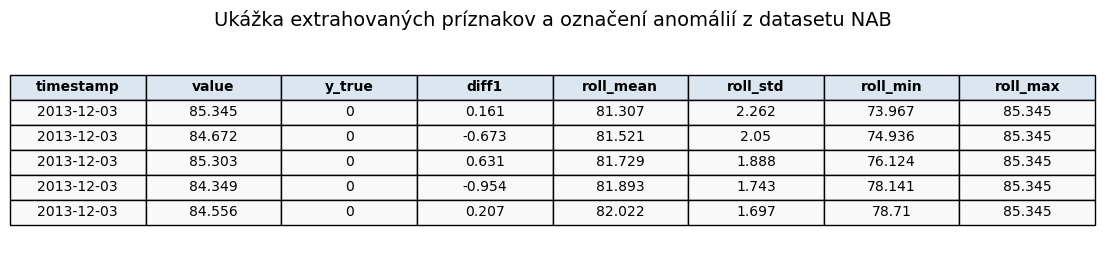


Základné štatistiky príznakov:
  Štatistika      value      diff1  roll_mean   roll_std   roll_min   roll_max
0      count  22646.000  22646.000  22646.000  22646.000  22646.000  22646.000
1       mean     85.937      0.001     85.922      2.340     81.634     89.905
2        std     13.760      1.077     13.306      2.637     15.178     12.188
3        min      2.085     -4.025     28.273      0.536      2.085     30.871
4        25%     83.139     -0.745     82.547      0.924     76.287     87.202
5        50%     89.435     -0.011     89.456      1.511     86.263     92.638
6        75%     94.034      0.728     93.707      2.628     91.000     96.740
7        max    108.511     19.881    105.135     36.388    102.100    108.511


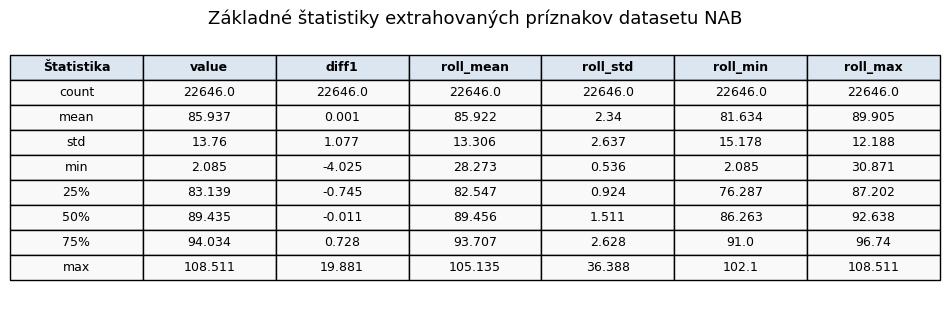

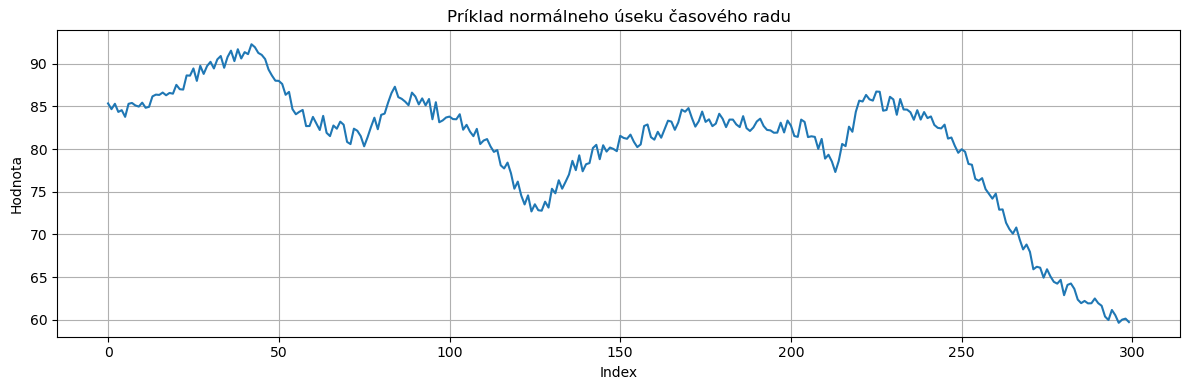

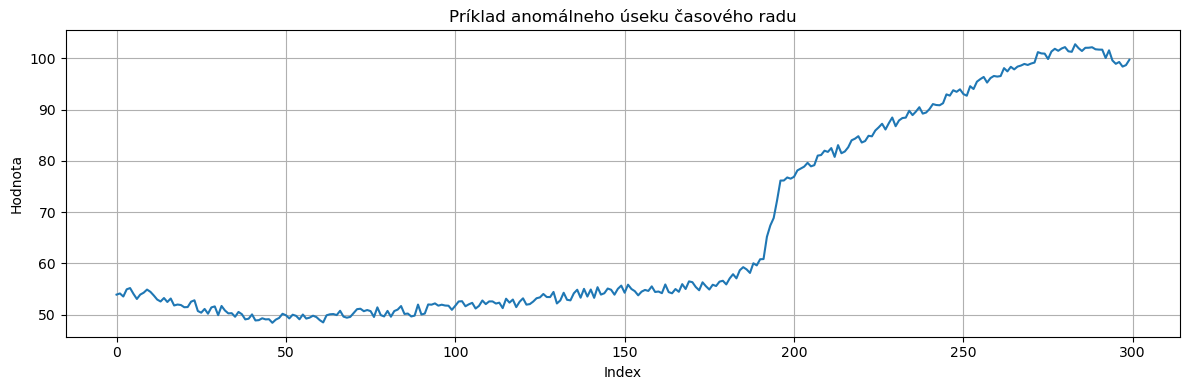

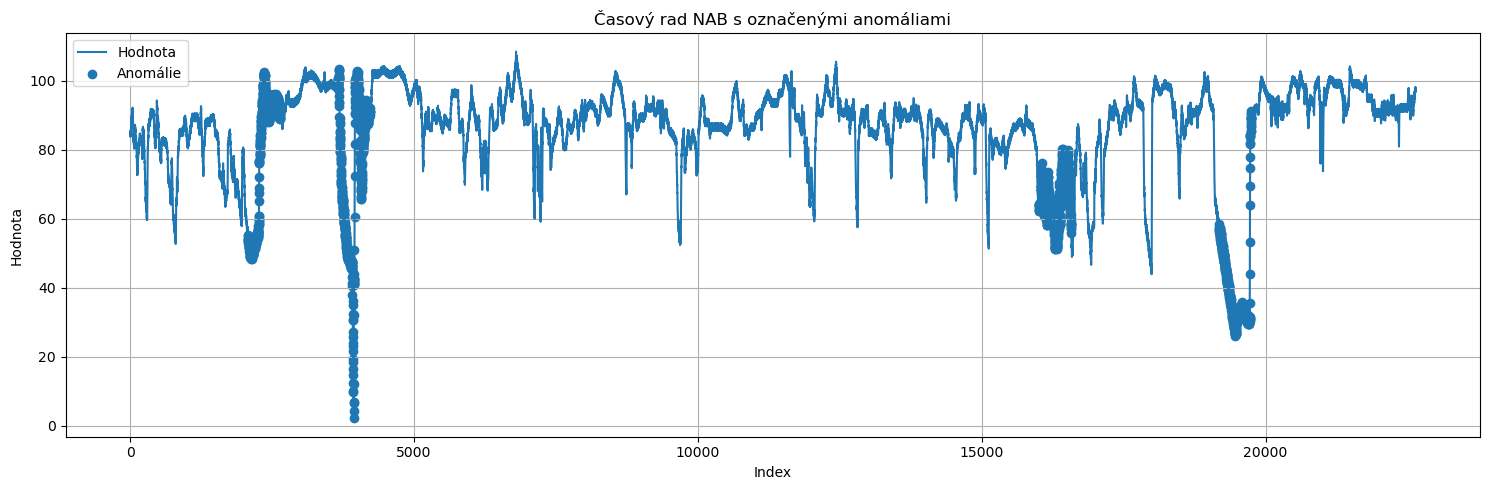

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("../data_processed")
df = pd.read_csv(base / "industrial_machine_features_labeled.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())

normal_count = int((df["y_true"] == 0).sum())
anomaly_count = int((df["y_true"] == 1).sum())
total_count = len(df)

split_df = pd.DataFrame({
    "Trieda": ["Normálne merania", "Anomálne merania", "Spolu"],
    "Počet riadkov": [normal_count, anomaly_count, total_count],
    "Podiel (%)": [
        round(normal_count / total_count * 100, 2),
        round(anomaly_count / total_count * 100, 2),
        100.00
    ]
})

print("\nRozdelenie meraní v datasete NAB:")
print(split_df)

split_df.to_csv(base / "nab_split_table.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.axis("off")

table = ax.table(
    cellText=split_df.values,
    colLabels=split_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dce6f1")
    else:
        cell.set_facecolor("#f9f9f9")

plt.title("Rozdelenie meraní na normálne a anomálne v datasete NAB", fontsize=13)
fig.savefig(base / "nab_split_table.png", dpi=300, bbox_inches="tight")
plt.show()

df_display = df.copy()

if "timestamp" in df_display.columns:
    df_display["timestamp"] = pd.to_datetime(df_display["timestamp"]).dt.strftime("%Y-%m-%d")

df_display = df_display.head().round(3)

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")

table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    loc="center",
    cellLoc="center"
)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dce6f1")
    else:
        cell.set_facecolor("#f9f9f9")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title(
    "Ukážka extrahovaných príznakov a označení anomálií z datasetu NAB",
    fontsize=14
)

fig.savefig(base / "industrial_table_labeled.png", dpi=300, bbox_inches="tight")
plt.show()

stats_df = df[["value", "diff1", "roll_mean", "roll_std", "roll_min", "roll_max"]].describe().round(3)
stats_df = stats_df.reset_index().rename(columns={"index": "Štatistika"})

print("\nZákladné štatistiky príznakov:")
print(stats_df)

stats_df.to_csv(base / "nab_feature_stats_table.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dce6f1")
    else:
        cell.set_facecolor("#f9f9f9")

plt.title("Základné štatistiky extrahovaných príznakov datasetu NAB", fontsize=13)
fig.savefig(base / "nab_feature_stats_table.png", dpi=300, bbox_inches="tight")
plt.show()

normal_df = df[df["y_true"] == 0].copy()

plt.figure(figsize=(12, 4))
plt.plot(range(len(normal_df.head(300))), normal_df["value"].head(300).values)
plt.title("Príklad normálneho úseku časového radu")
plt.xlabel("Index")
plt.ylabel("Hodnota")
plt.grid(True)
plt.tight_layout()
plt.savefig(base / "nab_normal_segment.png", dpi=300, bbox_inches="tight")
plt.show()

anomaly_df = df[df["y_true"] == 1].copy()

plt.figure(figsize=(12, 4))
plt.plot(range(len(anomaly_df.head(300))), anomaly_df["value"].head(300).values)
plt.title("Príklad anomálneho úseku časového radu")
plt.xlabel("Index")
plt.ylabel("Hodnota")
plt.grid(True)
plt.tight_layout()
plt.savefig(base / "nab_anomaly_segment.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(df["value"].values, label="Hodnota")
plt.scatter(
    df.index[df["y_true"] == 1],
    df.loc[df["y_true"] == 1, "value"],
    label="Anomálie",
    marker="o"
)

plt.title("Časový rad NAB s označenými anomáliami")
plt.xlabel("Index")
plt.ylabel("Hodnota")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(base / "nab_full_signal_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()